# ***Decision Tree Implementation — CART vs ID3.***

# **Import Libraries.**

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (confusion_matrix, accuracy_score,
                             precision_score, recall_score, f1_score,
                             roc_curve, auc)
from sklearn.decomposition import PCA
from sklearn.preprocessing import label_binarize

import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
sns.set_style("whitegrid")

print("All libraries imported successfully!")

All libraries imported successfully!


# **Load Dataset via Raw GitHub Link.**

In [47]:
url = "https://raw.githubusercontent.com/rubyat43/220143_DT_-_K_Means_Clustering/main/DT_Decision_Tree/dataset/iris.csv"

df = pd.read_csv(url)

print("Dataset loaded automatically from GitHub!")
print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print("\nFirst 5 rows:")
df.head()

Dataset loaded automatically from GitHub!
Shape: 150 rows × 6 columns

First 5 rows:


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


# ***Data Exploration.***
# **Basic Info.**

In [48]:
print("COLUMN NAMES & DATA TYPES")
print("\n")
print(df.dtypes)

print("\n")
print("DATASET SHAPE:")
print("\n")
print(f"  Rows    : {df.shape[0]}  → each row = 1 flower")
print(f"  Columns : {df.shape[1]}  → each column = 1 feature")

print("\n")
print("DATASET INFO:")
print("\n")
df.info()

COLUMN NAMES & DATA TYPES


Id                 int64
SepalLengthCm    float64
SepalWidthCm     float64
PetalLengthCm    float64
PetalWidthCm     float64
Species           object
dtype: object


DATASET SHAPE:


  Rows    : 150  → each row = 1 flower
  Columns : 6  → each column = 1 feature


DATASET INFO:


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


# **Missing Values.**

In [49]:
print("MISSING VALUES CHECK:")
print("\n")
missing = df.isnull().sum()
print(missing)
print(f"\nTotal missing values: {missing.sum()}")
if missing.sum() == 0:
    print("No missing values! Dataset is clean.")

print("\n")
print("CATEGORICAL FEATURES CHECK")
print("\n")
print(df['Species'].value_counts())
print(f"\nUnique species : {df['Species'].unique().tolist()}")
print("→ 'Species' column needs Label Encoding before training!")

MISSING VALUES CHECK:


Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

Total missing values: 0
No missing values! Dataset is clean.


CATEGORICAL FEATURES CHECK


Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

Unique species : ['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']
→ 'Species' column needs Label Encoding before training!


# **Statistical Summary.**

In [50]:
print("STATISTICAL SUMMARY")
print("\n")
df.describe().round(2)

STATISTICAL SUMMARY




,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.00,150.00,150.00,150.00,150.00
mean,75.50,5.84,3.05,3.76,1.20
std,43.45,0.83,0.43,1.76,0.76
min,1.00,4.30,2.00,1.00,0.10
25%,38.25,5.10,2.80,1.60,0.30
50%,75.50,5.80,3.00,4.35,1.30
75%,112.75,6.40,3.30,5.10,1.80
max,150.00,7.90,4.40,6.90,2.50


# **Detailed Feature Analysis.**

In [51]:
features = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']

for feat in features:
    print("\n")
    print(f"{feat}")
    print("\n")
    print(f"  Min     : {df[feat].min()}")
    print(f"  Max     : {df[feat].max()}")
    print(f"  Mean    : {df[feat].mean():.2f}")
    print(f"  Median  : {df[feat].median()}")
    print(f"  Std Dev : {df[feat].std():.2f}")
    print()



SepalLengthCm


  Min     : 4.3
  Max     : 7.9
  Mean    : 5.84
  Median  : 5.8
  Std Dev : 0.83



SepalWidthCm


  Min     : 2.0
  Max     : 4.4
  Mean    : 3.05
  Median  : 3.0
  Std Dev : 0.43



PetalLengthCm


  Min     : 1.0
  Max     : 6.9
  Mean    : 3.76
  Median  : 4.35
  Std Dev : 1.76



PetalWidthCm


  Min     : 0.1
  Max     : 2.5
  Mean    : 1.20
  Median  : 1.3
  Std Dev : 0.76



# **Species Distribution Plot.(Bar Chart, Pie Chart).**

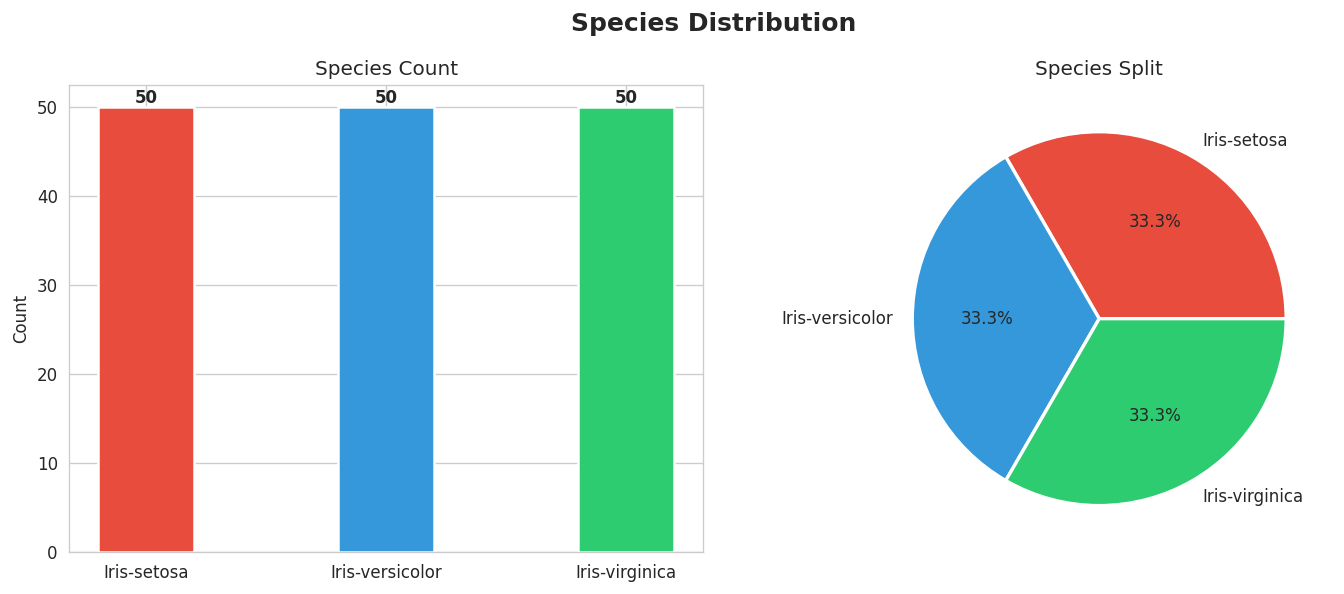

Species distribution plotted!


In [52]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Species Distribution', fontsize=15, fontweight='bold')

counts = df['Species'].value_counts()

axes[0].bar(counts.index, counts.values,
            color=['#e74c3c','#3498db','#2ecc71'],
            edgecolor='white', linewidth=1.5, width=0.4)
axes[0].set_title('Species Count')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v+0.5, str(v), ha='center', fontweight='bold')

axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=['#e74c3c','#3498db','#2ecc71'],
            wedgeprops={'edgecolor':'white','linewidth':2})
axes[1].set_title('Species Split')

plt.tight_layout()
plt.show()
print("Species distribution plotted!")

# **Feature Distributions.**

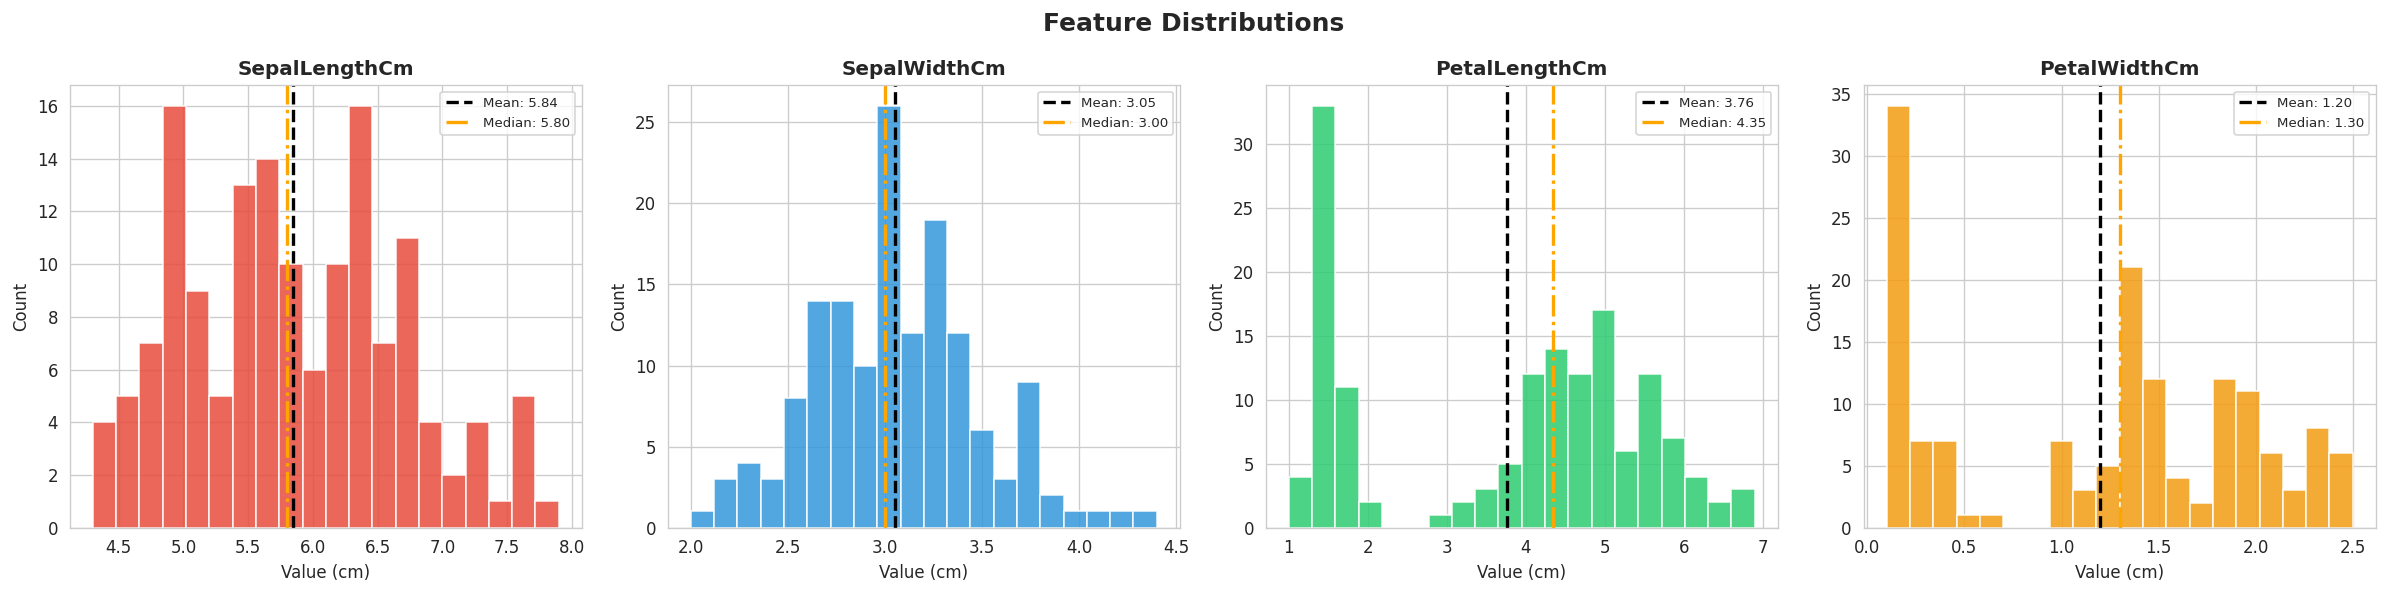

Feature distributions plotted!


In [53]:
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle('Feature Distributions', fontsize=15, fontweight='bold')

for i, (feat, color) in enumerate(zip(features, colors)):
    axes[i].hist(df[feat], bins=20, color=color, edgecolor='white', alpha=0.85)
    axes[i].axvline(df[feat].mean(), color='black', linestyle='--',
                    linewidth=2, label=f'Mean: {df[feat].mean():.2f}')
    axes[i].axvline(df[feat].median(), color='orange', linestyle='-.',
                    linewidth=2, label=f'Median: {df[feat].median():.2f}')
    axes[i].set_title(feat, fontweight='bold')
    axes[i].set_xlabel('Value (cm)')
    axes[i].set_ylabel('Count')
    axes[i].legend(fontsize=8)

plt.tight_layout()
plt.show()
print("Feature distributions plotted!")

# **Boxplots by Species.**

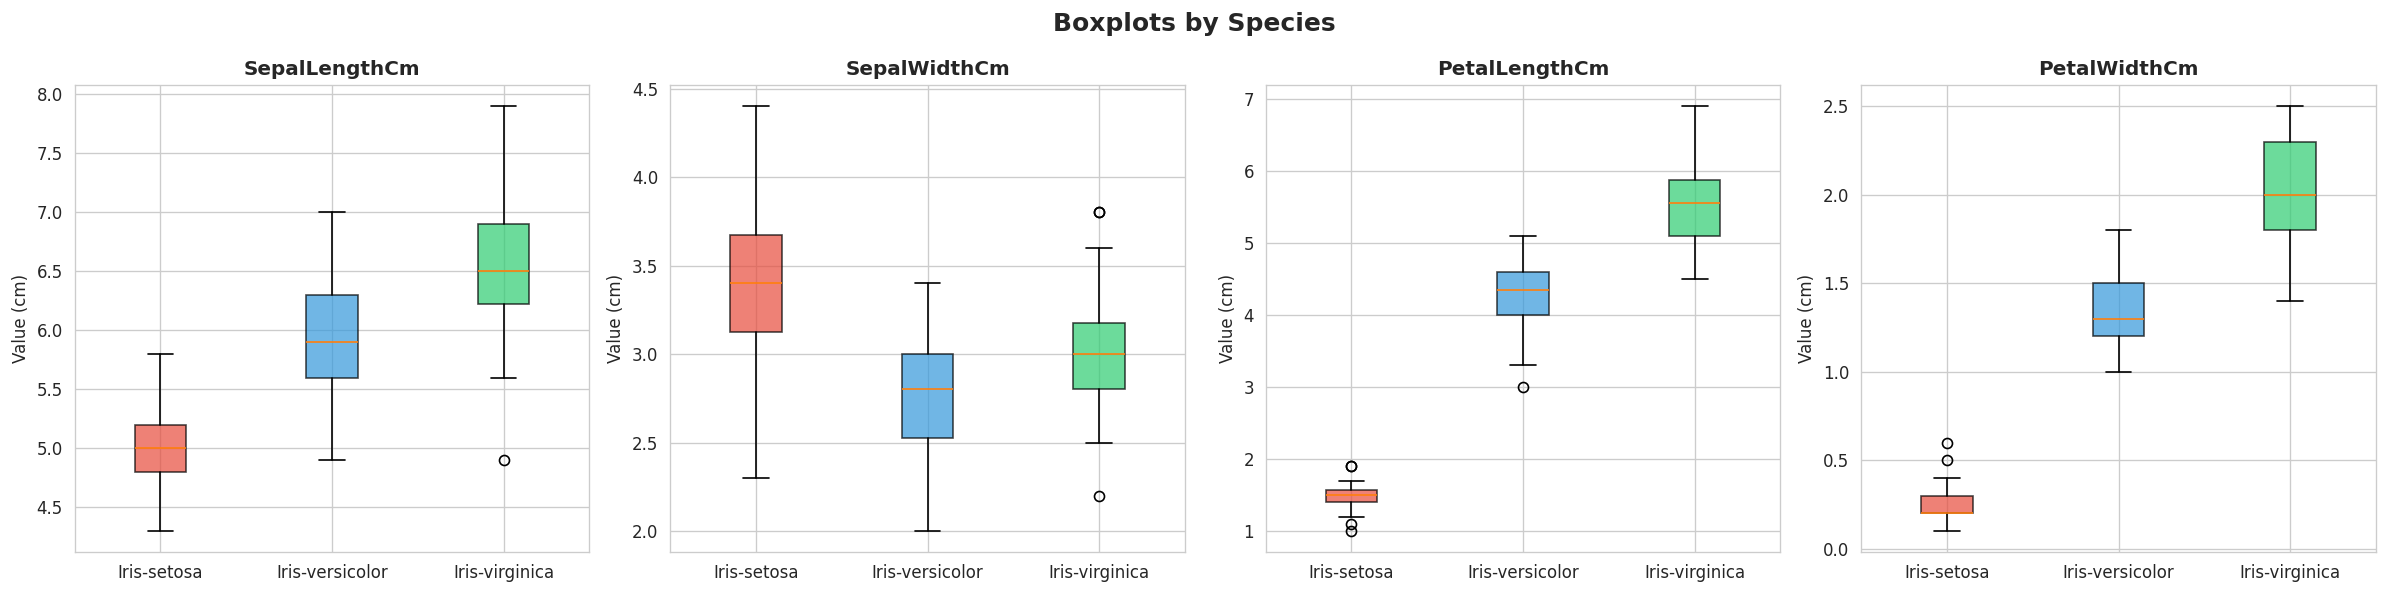

Boxplots plotted!


In [54]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle('Boxplots by Species', fontsize=15, fontweight='bold')

for i, feat in enumerate(features):
    species_list = df['Species'].unique()
    data = [df[df['Species']==s][feat].values for s in species_list]
    bp = axes[i].boxplot(data, patch_artist=True, labels=species_list)
    for patch, color in zip(bp['boxes'], ['#e74c3c','#3498db','#2ecc71']):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    axes[i].set_title(feat, fontweight='bold')
    axes[i].set_ylabel('Value (cm)')

plt.tight_layout()
plt.show()
print("Boxplots plotted!")

# **Correlation Heatmap.**

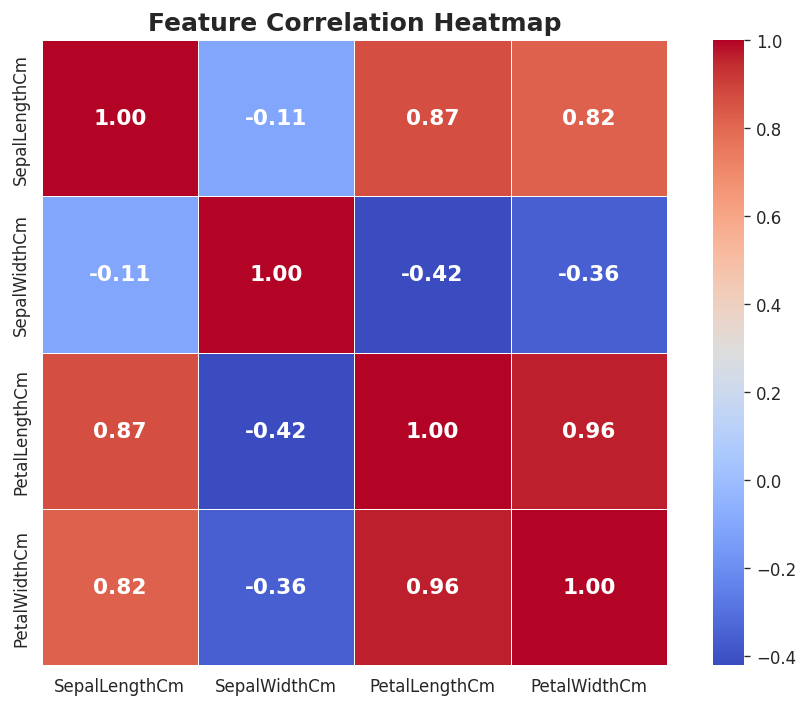

Correlation heatmap plotted!


In [55]:
plt.figure(figsize=(8, 6))
corr = df[features].corr()

sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm',
            linewidths=0.5, square=True,
            annot_kws={"size": 13, "weight": "bold"})

plt.title('Feature Correlation Heatmap', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()
print("Correlation heatmap plotted!")

# **Pairplot.**

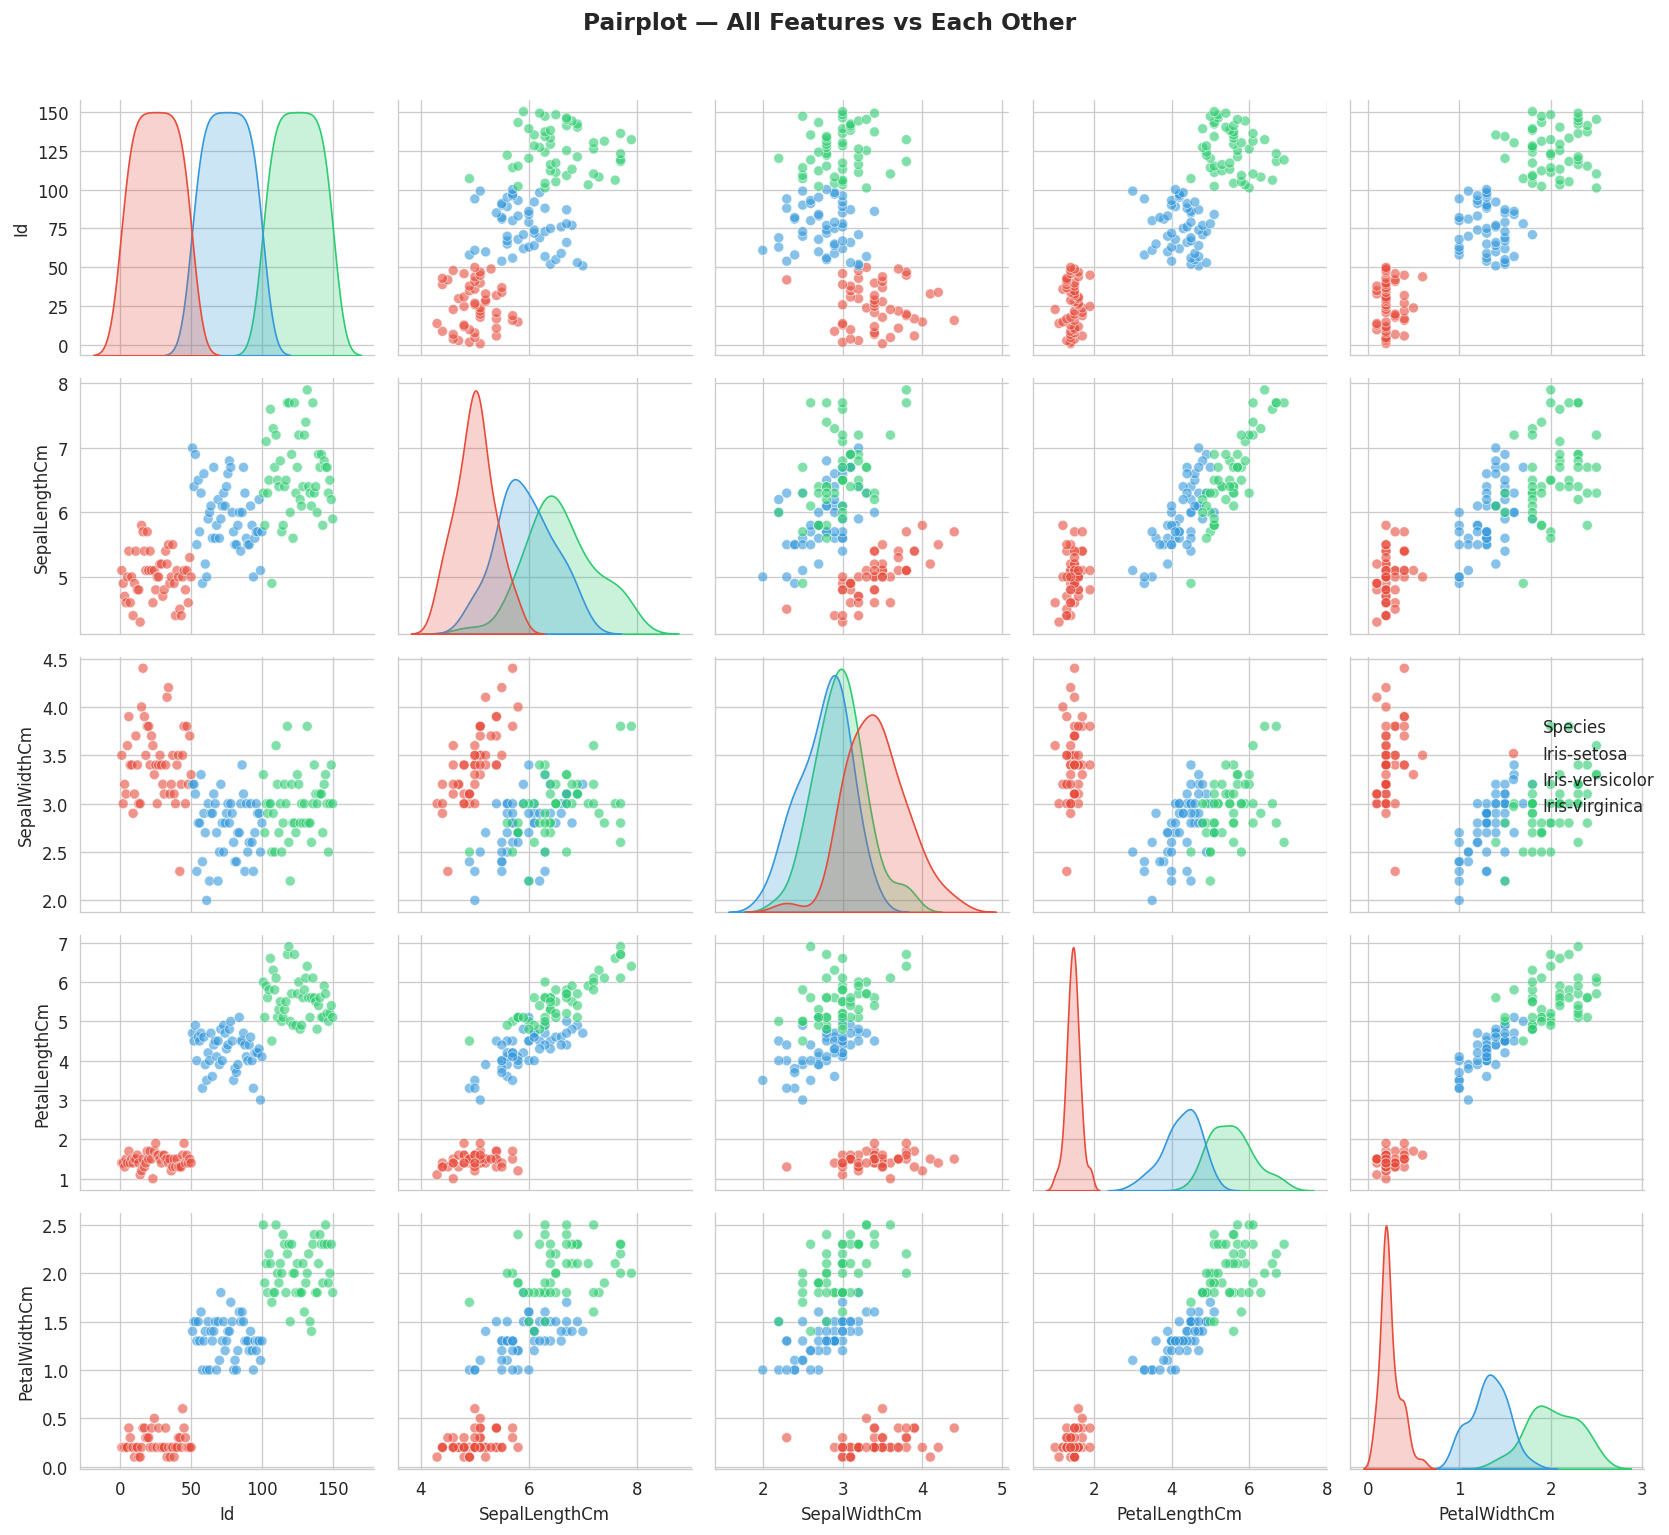

Pairplot done!


In [56]:
sns.pairplot(df, hue='Species',
             palette={'Iris-setosa':'#e74c3c',
                      'Iris-versicolor':'#3498db',
                      'Iris-virginica':'#2ecc71'},
             diag_kind='kde',
             plot_kws={'alpha':0.6})

plt.suptitle('Pairplot — All Features vs Each Other',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print("Pairplot done!")

# ***Data Preprocessing.***


In [57]:
df.fillna(df.mean(numeric_only=True), inplace=True)

le = LabelEncoder()
df['species_encoded'] = le.fit_transform(df['Species'])

print("\n")
print("LABEL ENCODING — Categorical Feature Handled")
print("\n")
for i, cls in enumerate(le.classes_):
    print(f"  {cls} → {i}")

X = df[features].values
y = df['species_encoded'].values

print(f"\nFeatures shape : {X.shape}")
print(f"Target shape   : {y.shape}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nTraining samples : {X_train.shape[0]}")
print(f"Test samples     : {X_test.shape[0]}")
print("\nPreprocessing complete!")



LABEL ENCODING — Categorical Feature Handled


  Iris-setosa → 0
  Iris-versicolor → 1
  Iris-virginica → 2

Features shape : (150, 4)
Target shape   : (150,)

Training samples : 120
Test samples     : 30

Preprocessing complete!


# ***CART Implementation (Gini Criterion)/ CART Tuning with Cross Validation.***


In [58]:
param_grid = {
    'max_depth': [2, 3, 4, 5, 6, 7, None],
    'min_samples_split': [2, 5, 10, 15, 20]
}

cart = DecisionTreeClassifier(criterion='gini', random_state=42)
grid_cart = GridSearchCV(cart, param_grid, cv=5,
                         scoring='accuracy', n_jobs=-1)
grid_cart.fit(X_train, y_train)

print("CART (GINI) — CROSS VALIDATION RESULTS")
print("\n")
print(f"  Best max_depth         : {grid_cart.best_params_['max_depth']}")
print(f"  Best min_samples_split : {grid_cart.best_params_['min_samples_split']}")
print(f"  Best CV Accuracy       : {grid_cart.best_score_*100:.2f}%")

cart_best = grid_cart.best_estimator_
print("\nCART model trained with best parameters!")

CART (GINI) — CROSS VALIDATION RESULTS


  Best max_depth         : 4
  Best min_samples_split : 2
  Best CV Accuracy       : 94.17%

CART model trained with best parameters!


# ***ID3 Implementation (Entropy Criterion)/ ID3 Tuning with Cross Validation.***

In [59]:
id3 = DecisionTreeClassifier(criterion='entropy', random_state=42)
grid_id3 = GridSearchCV(id3, param_grid, cv=5,
                        scoring='accuracy', n_jobs=-1)
grid_id3.fit(X_train, y_train)

print("ID3 (ENTROPY) — CROSS VALIDATION RESULTS")
print("\n")
print(f"  Best max_depth         : {grid_id3.best_params_['max_depth']}")
print(f"  Best min_samples_split : {grid_id3.best_params_['min_samples_split']}")
print(f"  Best CV Accuracy       : {grid_id3.best_score_*100:.2f}%")

id3_best = grid_id3.best_estimator_
print("\nID3 model trained with best parameters!")

ID3 (ENTROPY) — CROSS VALIDATION RESULTS


  Best max_depth         : 5
  Best min_samples_split : 2
  Best CV Accuracy       : 93.33%

ID3 model trained with best parameters!


# ***Visualizations — CART vs ID3 (2x1 Comparison).***
# **Confusion Matrix 2x1.**

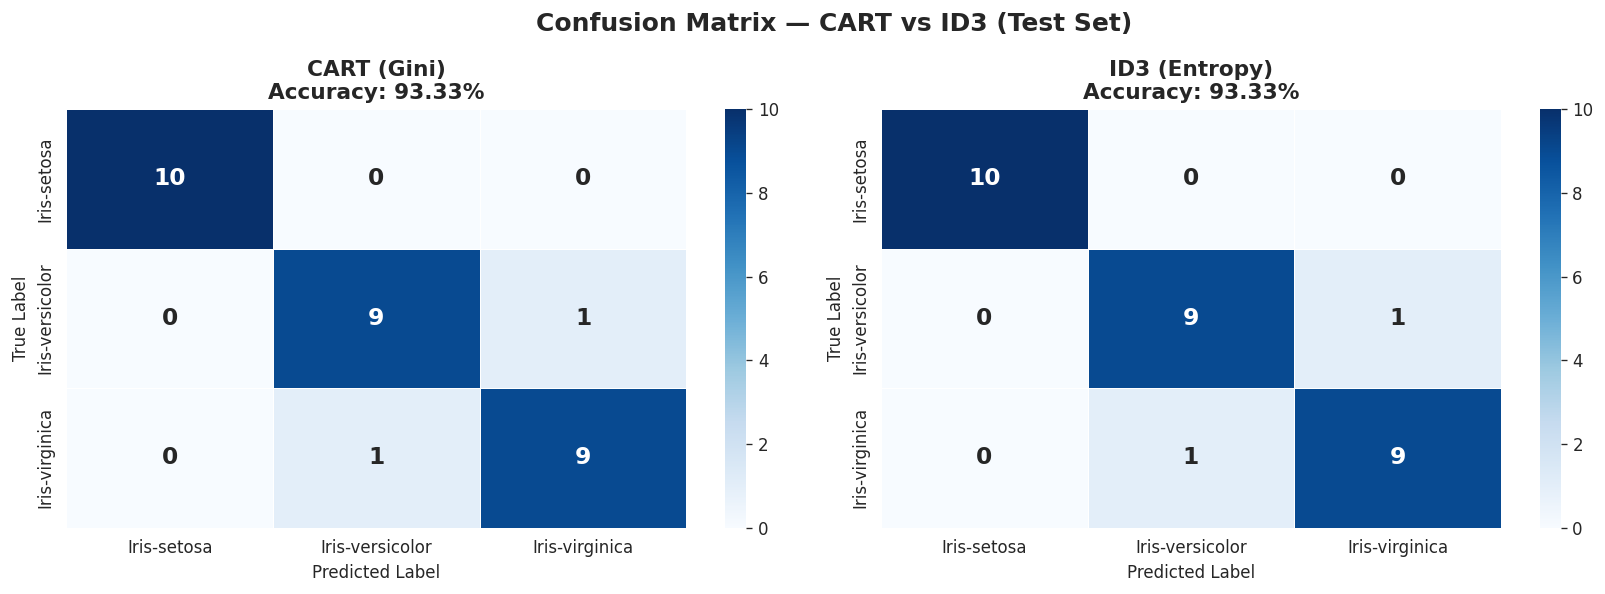

Confusion matrix plotted!


In [60]:
models = [('CART (Gini)', cart_best), ('ID3 (Entropy)', id3_best)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Confusion Matrix — CART vs ID3 (Test Set)',
             fontsize=15, fontweight='bold')

for ax, (name, model) in zip(axes, models):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=le.classes_,
                yticklabels=le.classes_,
                ax=ax, linewidths=0.5,
                annot_kws={"size": 14, "weight": "bold"})
    acc = accuracy_score(y_test, y_pred)
    ax.set_title(f'{name}\nAccuracy: {acc*100:.2f}%',
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=100, bbox_inches='tight')
plt.show()
print("Confusion matrix plotted!")

# **ROC Curve 2x1.**

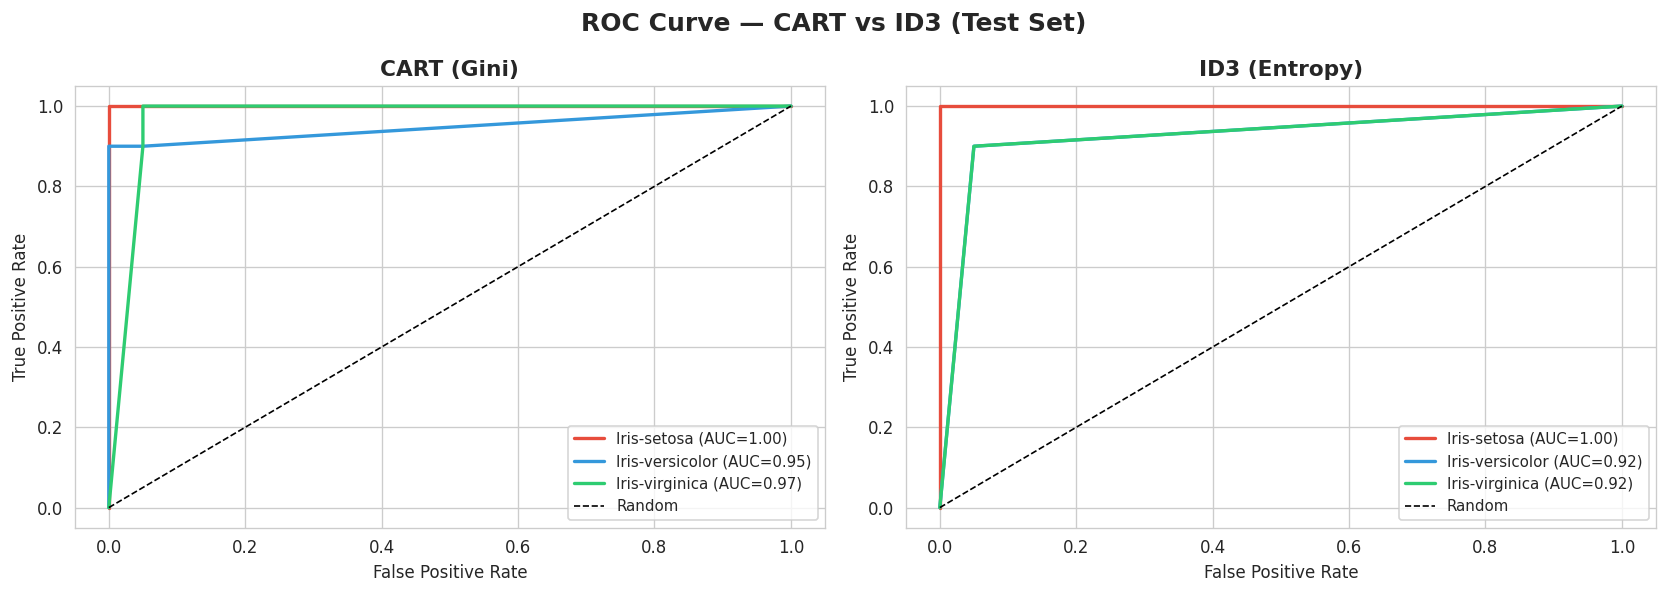

ROC curves plotted!


In [61]:
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
colors_roc = ['#e74c3c', '#3498db', '#2ecc71']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('ROC Curve — CART vs ID3 (Test Set)',
             fontsize=15, fontweight='bold')

for ax, (name, model) in zip(axes, models):
    y_score = model.predict_proba(X_test)
    for i, (cls, color) in enumerate(zip(le.classes_, colors_roc)):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=color, linewidth=2,
                label=f'{cls} (AUC={roc_auc:.2f})')
    ax.plot([0,1],[0,1],'k--', linewidth=1, label='Random')
    ax.set_title(name, fontsize=13, fontweight='bold')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('roc_curve.png', dpi=100, bbox_inches='tight')
plt.show()
print("ROC curves plotted!")

# **Decision Boundary 2x1.**

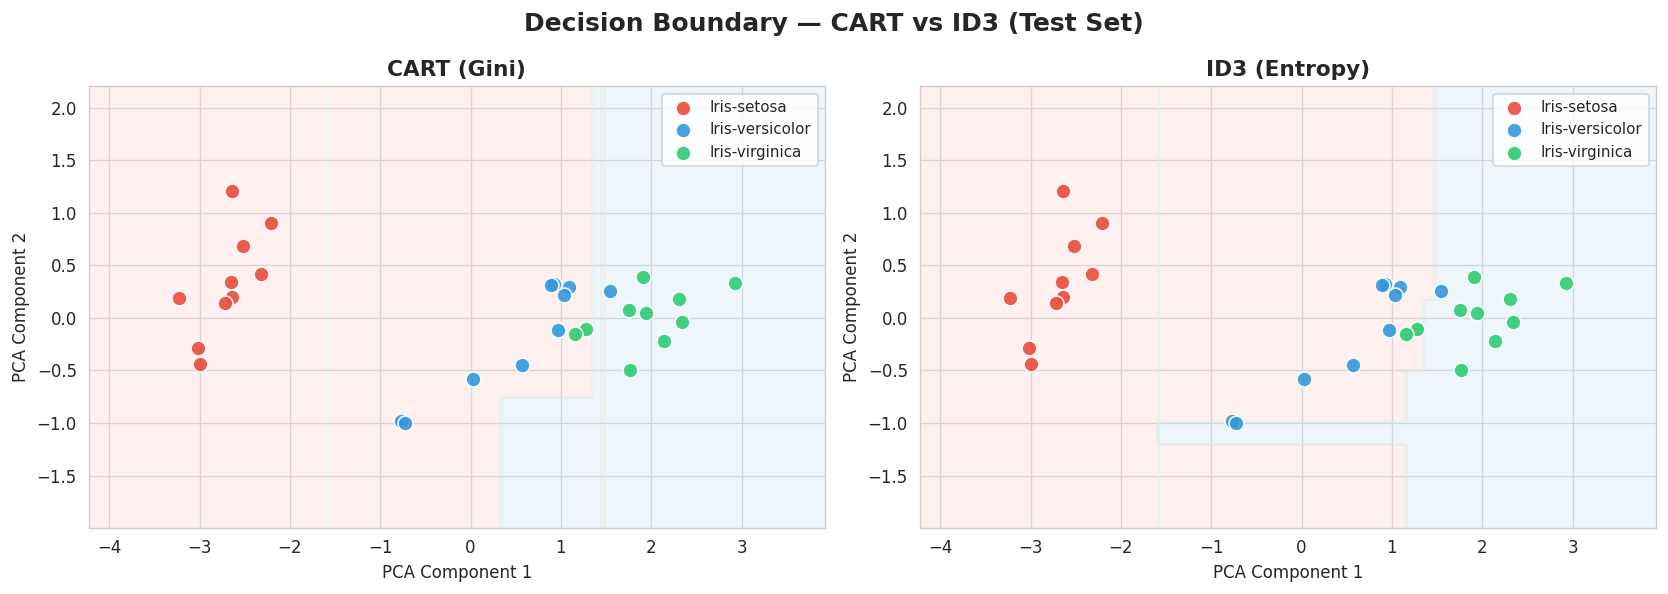

Decision boundaries plotted!


In [62]:
pca = PCA(n_components=2)
X_train_2d = pca.fit_transform(X_train)
X_test_2d  = pca.transform(X_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Decision Boundary — CART vs ID3 (Test Set)',
             fontsize=15, fontweight='bold')

boundary_colors = ['#fadbd8', '#d6eaf8', '#d5f5e3']
point_colors    = ['#e74c3c', '#3498db', '#2ecc71']

for ax, (name, model) in zip(axes, models):
    model_2d = DecisionTreeClassifier(
        criterion=model.criterion,
        max_depth=model.max_depth,
        min_samples_split=model.min_samples_split,
        random_state=42)
    model_2d.fit(X_train_2d, y_train)

    x_min, x_max = X_test_2d[:,0].min()-1, X_test_2d[:,0].max()+1
    y_min, y_max = X_test_2d[:,1].min()-1, X_test_2d[:,1].max()+1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))
    Z = model_2d.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.4, colors=boundary_colors)

    for i, color in enumerate(point_colors):
        mask = y_test == i
        ax.scatter(X_test_2d[mask, 0], X_test_2d[mask, 1],
                   c=color, edgecolors='white', s=80,
                   label=le.classes_[i], alpha=0.9)

    ax.set_title(name, fontsize=13, fontweight='bold')
    ax.set_xlabel('PCA Component 1')
    ax.set_ylabel('PCA Component 2')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('decision_boundary.png', dpi=100, bbox_inches='tight')
plt.show()
print("Decision boundaries plotted!")

# **Evaluation Metrics Bar Chart.**



EVALUATION METRICS — CART vs ID3


Metric        CART (Gini)  ID3 (Entropy)
----------------------------------------
Accuracy           0.9333         0.9333
Precision          0.9333         0.9333
Recall             0.9333         0.9333
F1 Score           0.9333         0.9333
AUC                0.9733         0.9500


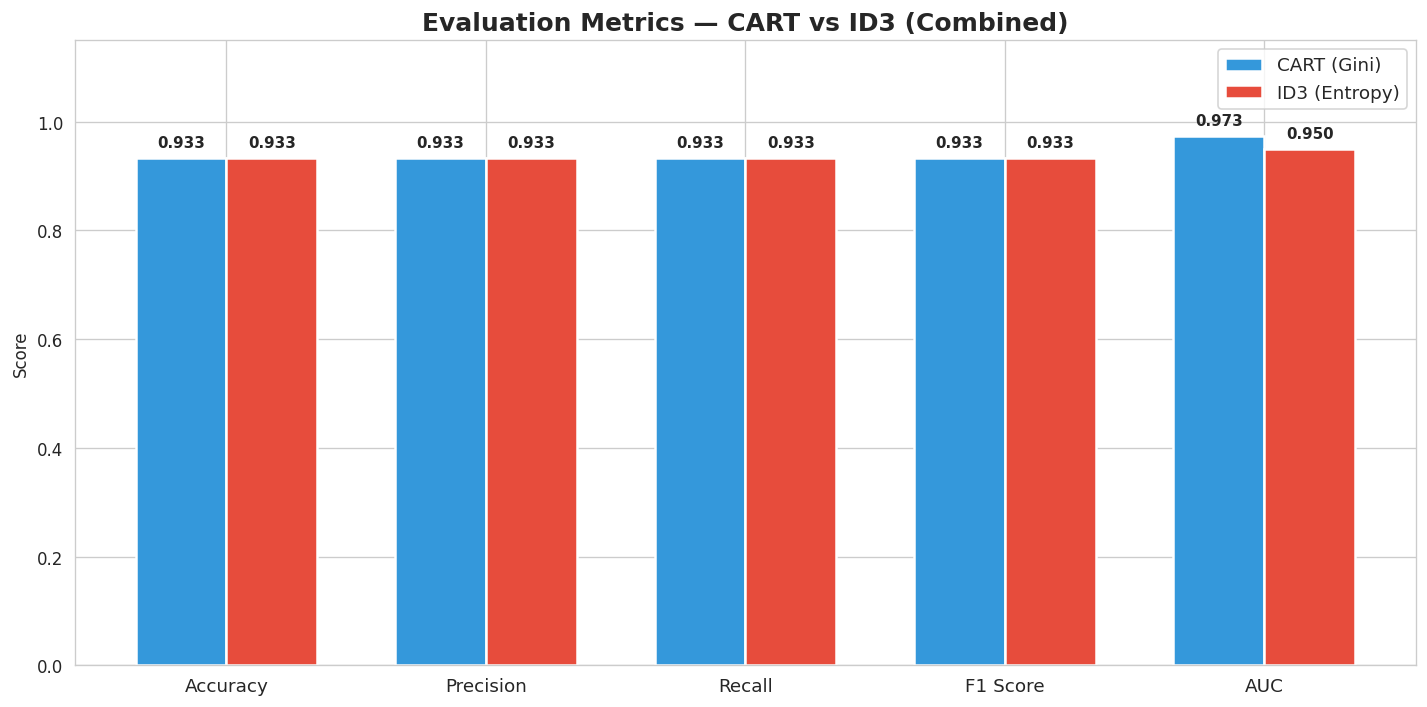

Metrics bar chart plotted!


In [63]:
def get_metrics(model, X_test, y_test):
    y_pred  = model.predict(X_test)
    y_score = model.predict_proba(X_test)
    y_bin   = label_binarize(y_test, classes=[0,1,2])

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted')
    rec  = recall_score(y_test, y_pred, average='weighted')
    f1   = f1_score(y_test, y_pred, average='weighted')

    auc_scores = []
    for i in range(3):
        fpr, tpr, _ = roc_curve(y_bin[:,i], y_score[:,i])
        auc_scores.append(auc(fpr, tpr))
    avg_auc = np.mean(auc_scores)

    return [acc, prec, rec, f1, avg_auc]

cart_metrics = get_metrics(cart_best, X_test, y_test)
id3_metrics  = get_metrics(id3_best,  X_test, y_test)
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'AUC']

print("\n")
print("EVALUATION METRICS — CART vs ID3")
print("\n")
print(f"{'Metric':<12} {'CART (Gini)':>12} {'ID3 (Entropy)':>14}")
print("-"*40)
for name, c, i in zip(metric_names, cart_metrics, id3_metrics):
    print(f"{name:<12} {c:>12.4f} {i:>14.4f}")

x = np.arange(len(metric_names))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, cart_metrics, width,
               label='CART (Gini)', color='#3498db',
               edgecolor='white', linewidth=1.5)
bars2 = ax.bar(x + width/2, id3_metrics, width,
               label='ID3 (Entropy)', color='#e74c3c',
               edgecolor='white', linewidth=1.5)

ax.set_title('Evaluation Metrics — CART vs ID3 (Combined)',
             fontsize=15, fontweight='bold')
ax.set_ylabel('Score')
ax.set_xticks(x)
ax.set_xticklabels(metric_names, fontsize=11)
ax.set_ylim(0, 1.15)
ax.legend(fontsize=11)

for bar in bars1:
    ax.text(bar.get_x()+bar.get_width()/2,
            bar.get_height()+0.02,
            f'{bar.get_height():.3f}',
            ha='center', fontsize=9, fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x()+bar.get_width()/2,
            bar.get_height()+0.02,
            f'{bar.get_height():.3f}',
            ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('metrics.png', dpi=100, bbox_inches='tight')
plt.show()
print("Metrics bar chart plotted!")

# **DT Structure (Single Image).**

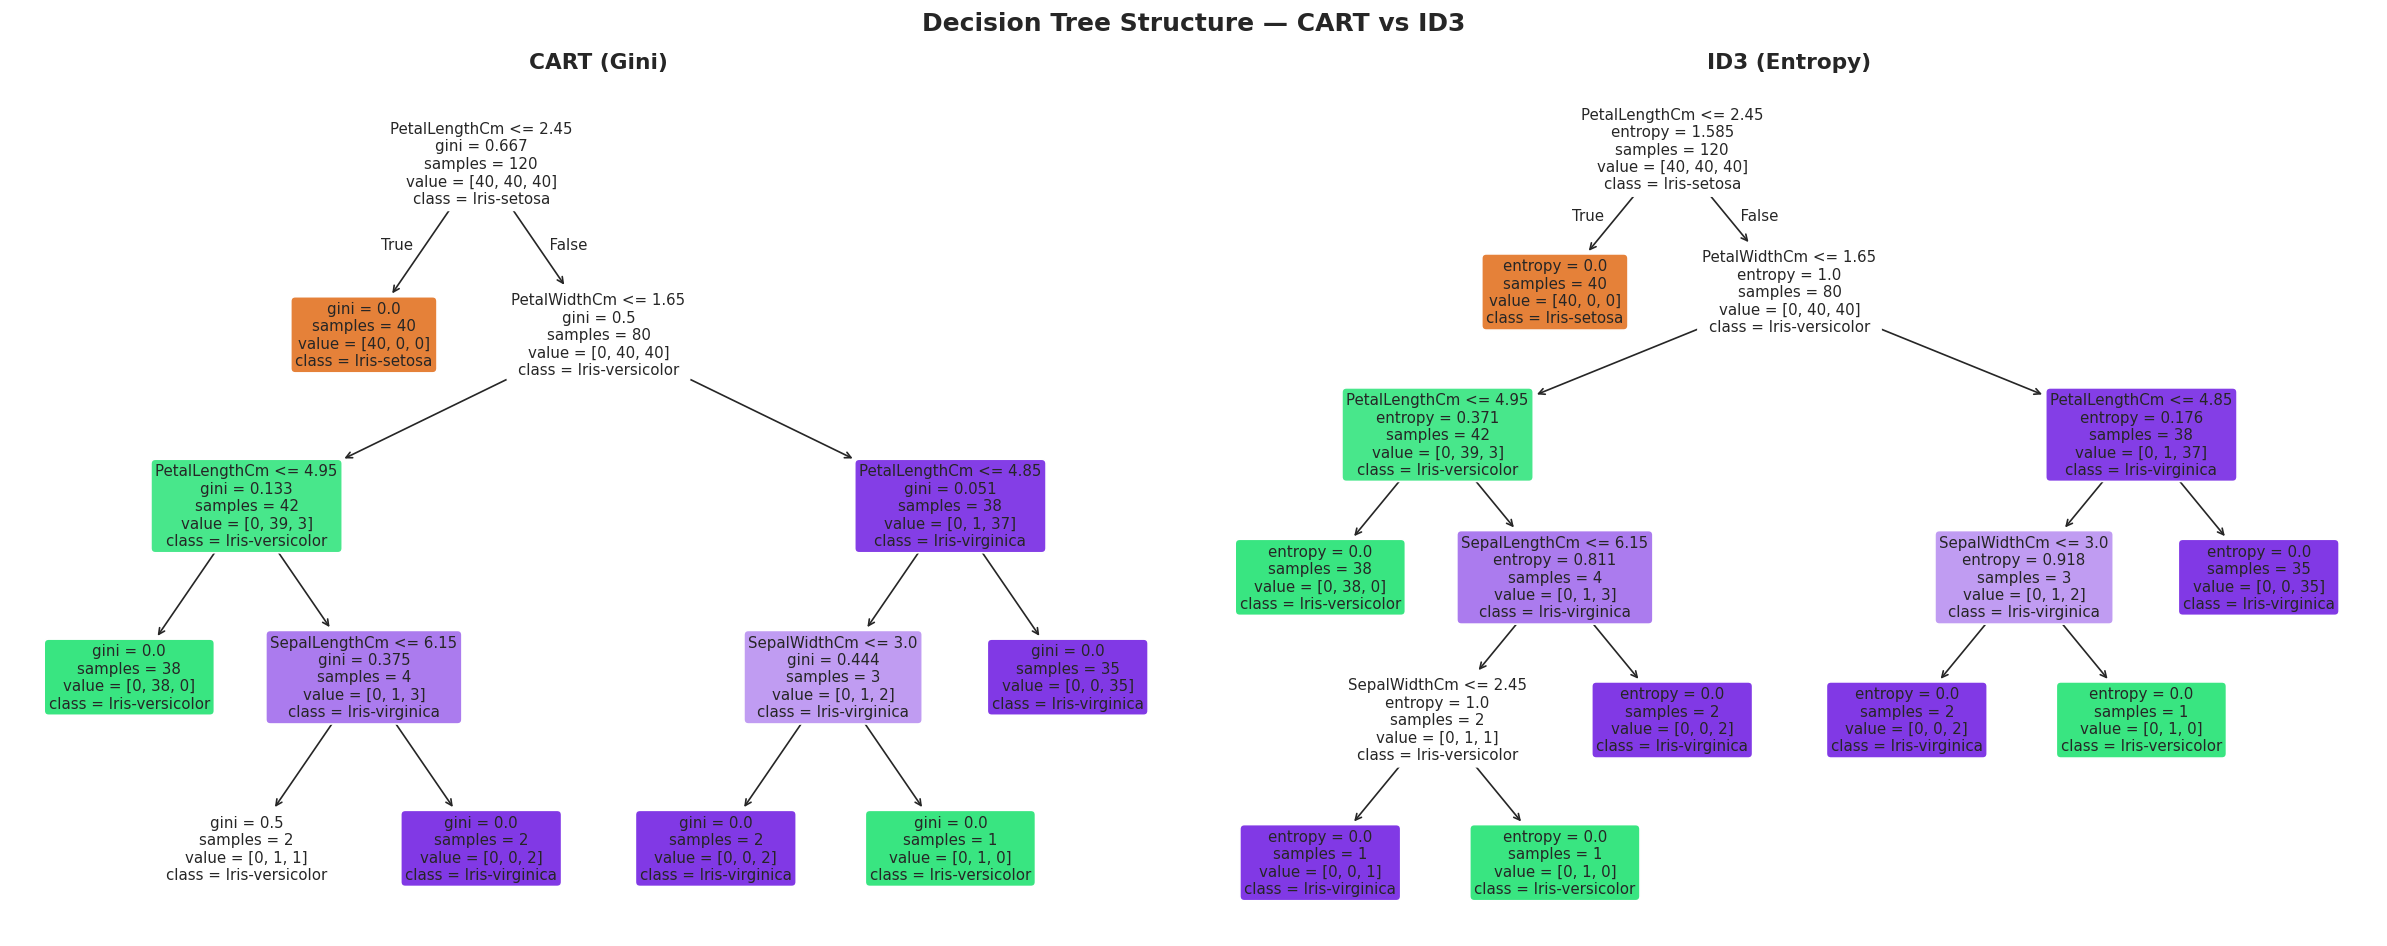

Tree structure plotted!


In [64]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
fig.suptitle('Decision Tree Structure — CART vs ID3',
             fontsize=15, fontweight='bold')

for ax, (name, model) in zip(axes, models):
    plot_tree(model,
              feature_names=features,
              class_names=le.classes_,
              filled=True,
              rounded=True,
              fontsize=9,
              ax=ax)
    ax.set_title(name, fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('tree_structure.png', dpi=100, bbox_inches='tight')
plt.show()
print("Tree structure plotted!")

# **Final Summary.**

In [65]:
print("ASSIGNMENT COMPLETE — FINAL SUMMARY")
print("\n")
print(f"  Dataset           : Iris (150 samples, 4 features)")
print(f"  Training samples  : {X_train.shape[0]}")
print(f"  Test samples      : {X_test.shape[0]}")
print(f"\n  CART (Gini):")
print(f"     max_depth         : {grid_cart.best_params_['max_depth']}")
print(f"     min_samples_split : {grid_cart.best_params_['min_samples_split']}")
print(f"     Test Accuracy     : {cart_metrics[0]*100:.2f}%")
print(f"\n    ID3 (Entropy):")
print(f"     max_depth         : {grid_id3.best_params_['max_depth']}")
print(f"     min_samples_split : {grid_id3.best_params_['min_samples_split']}")
print(f"     Test Accuracy     : {id3_metrics[0]*100:.2f}%")
print(f"\n    GitHub : https://github.com/rubyat43/220143_DT_-_K_Means_Clustering")
print("\n")

ASSIGNMENT COMPLETE — FINAL SUMMARY


  Dataset           : Iris (150 samples, 4 features)
  Training samples  : 120
  Test samples      : 30

  CART (Gini):
     max_depth         : 4
     min_samples_split : 2
     Test Accuracy     : 93.33%

    ID3 (Entropy):
     max_depth         : 5
     min_samples_split : 2
     Test Accuracy     : 93.33%

    GitHub : https://github.com/rubyat43/220143_DT_-_K_Means_Clustering




# **Download All Plots.**

In [66]:
from google.colab import files

files.download('confusion_matrix.png')
files.download('roc_curve.png')
files.download('decision_boundary.png')
files.download('metrics.png')
files.download('tree_structure.png')

print("All 5 plots downloaded!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

All 5 plots downloaded!
